# Server downtime prediction

This notebook trains a regression model for `Downtime (Min)` from the `Fail Logs` worksheet. July-November is the training period and December is held out as the test set.

## Environment update

Run the next cell once if pandas reports an `openpyxl` or `bottleneck` version error. Restart the notebook kernel after installation, then run all cells from the beginning.

In [1]:
%pip install --upgrade "openpyxl>=3.1.5" "bottleneck>=1.3.6"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
DATA_PATH = Path.cwd() / "Task Data_ Server Down Data.xlsx"
OUTPUT_DIR = Path.cwd() / "output" / "ml"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Workbook not found: {DATA_PATH}")

print(f"Loading: {DATA_PATH}")
print(f"Saving model outputs to: {OUTPUT_DIR}")

Loading: c:\Users\user\Documents\GitHub\Data_Analysis_Fujitsu\Task Data_ Server Down Data.xlsx
Saving model outputs to: c:\Users\user\Documents\GitHub\Data_Analysis_Fujitsu\output\ml


In [3]:
def load_fail_logs(path: Path) -> pd.DataFrame:
    frame = pd.read_excel(path, sheet_name="Fail Logs").dropna(how="all").copy()
    required = {"Asset ID", "Downtime (Min)", "Fail Date", "Office", "Event Notes"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    frame["Asset ID"] = pd.to_numeric(frame["Asset ID"], errors="coerce")
    frame["Downtime (Min)"] = pd.to_numeric(frame["Downtime (Min)"], errors="coerce")
    frame["Fail Date"] = pd.to_datetime(frame["Fail Date"], errors="coerce")
    for column in ["Office", "Event Notes"]:
        frame[column] = frame[column].fillna("Unknown").astype(str).str.strip()

    frame = frame.dropna(subset=["Asset ID", "Downtime (Min)", "Fail Date"]).copy()
    frame["Fail Month"] = frame["Fail Date"].dt.month_name()
    return frame.sort_values("Fail Date").reset_index(drop=True)


df = load_fail_logs(DATA_PATH)
month_order = ["July", "August", "September", "October", "November", "December"]
df = df[df["Fail Month"].isin(month_order)].copy()

if df.empty:
    raise ValueError("No valid July-December fail-log records were found.")

print(f"Rows after cleaning: {len(df)}")
display(df.groupby("Fail Month").size().reindex(month_order).fillna(0).astype(int).rename("records"))

Rows after cleaning: 40


Fail Month
July         5
August       7
September    7
October      7
November     6
December     8
Name: records, dtype: int32

## Feature extraction and feature selection

The model uses five selected predictors: asset, office, failure cause, failure month, and day of week. Redundant interaction and calendar fields are excluded to reduce overfitting on this small dataset. The target (`Downtime (Min)`) and raw date are excluded from the feature matrix to prevent target leakage. Feature extraction and selection happen before the time-aware train/test split; model preprocessing is still fitted only on the training data through the pipeline.

In [4]:
def make_features(frame: pd.DataFrame) -> pd.DataFrame:
    features = frame[["Asset ID", "Fail Date", "Office", "Event Notes"]].copy()
    features["Asset ID"] = features["Asset ID"].astype("Int64").astype(str)
    features["fail_year"] = features["Fail Date"].dt.year
    features["fail_month_number"] = features["Fail Date"].dt.month
    features["fail_day_of_week"] = features["Fail Date"].dt.dayofweek
    features["fail_day_of_month"] = features["Fail Date"].dt.day
    features["office_cause"] = features["Office"] + " | " + features["Event Notes"]
    features["cause_is_network"] = features["Event Notes"].str.contains("Network", case=False, na=False).astype(int)
    features["cause_is_storage"] = features["Event Notes"].str.contains("storage", case=False, na=False).astype(int)
    return features.drop(columns=["Fail Date"])


TARGET = "Downtime (Min)"
# Keep a compact five-feature set to reduce overfitting on the small dataset.
selected_features = ["Asset ID", "Office", "Event Notes", "fail_month_number", "fail_day_of_week"]

# Extract features for the complete cleaned dataset, then select the predictors.
X_all = make_features(df).loc[:, selected_features]
y_all = df[TARGET].copy()

# Keep December completely separate as the final time-based test set.
train_mask = df["Fail Month"].isin(month_order[:-1])
test_mask = df["Fail Month"].eq("December")
X_train = X_all.loc[train_mask].copy()
X_test = X_all.loc[test_mask].copy()
y_train = y_all.loc[train_mask].copy()
y_test = y_all.loc[test_mask].copy()

if X_train.empty or X_test.empty:
    raise ValueError("Both the July-November training set and December test set must contain rows.")

categorical_features = ["Asset ID", "Office", "Event Notes"]
numeric_features = ["fail_month_number", "fail_day_of_week"]
preprocessor = ColumnTransformer(
    [
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)
print(f"Selected features: {selected_features}")
print(f"Training rows: {len(X_train)}")
print(f"December test rows: {len(X_test)}")
print(f"Training dates: {df.loc[train_mask, 'Fail Date'].min().date()} to {df.loc[train_mask, 'Fail Date'].max().date()}")
print(f"Test dates: {df.loc[test_mask, 'Fail Date'].min().date()} to {df.loc[test_mask, 'Fail Date'].max().date()}")

Selected features: ['Asset ID', 'Office', 'Event Notes', 'fail_month_number', 'fail_day_of_week']
Training rows: 32
December test rows: 8
Training dates: 2019-07-04 to 2019-11-22
Test dates: 2019-12-06 to 2019-12-30


In [5]:
# Keep these imports in the model-search cell so it can be rerun independently.
from sklearn.tree import DecisionTreeRegressor

candidate_estimators = {
    "Random forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra trees": ExtraTreesRegressor(
        n_estimators=500,
        max_features=0.8,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=2,
        loss="huber",
        random_state=RANDOM_STATE,
    ),
    "Random forest absolute error": RandomForestRegressor(
        n_estimators=500,
        criterion="absolute_error",
        max_depth=4,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Random forest regularized": RandomForestRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=2,
        max_features=0.7,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra trees absolute error": ExtraTreesRegressor(
        n_estimators=500,
        criterion="absolute_error",
        max_features=0.8,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient boosting absolute error": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=2,
        loss="absolute_error",
        random_state=RANDOM_STATE,
    ),
    "Gradient boosting shallow": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.02,
        max_depth=1,
        min_samples_leaf=2,
        loss="huber",
        random_state=RANDOM_STATE,
    ),
    "Decision tree absolute error": DecisionTreeRegressor(
        criterion="absolute_error",
        max_depth=3,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
}

def regression_metrics(actual: pd.Series, predicted: np.ndarray) -> dict[str, float]:
    return {
        "MAE (minutes)": mean_absolute_error(actual, predicted),
        "RMSE (minutes)": mean_squared_error(actual, predicted) ** 0.5,
        "R-squared": r2_score(actual, predicted),
    }

baseline = DummyRegressor(strategy="mean")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
baseline_pred = baseline.predict(np.zeros((len(y_test), 1)))
results = [{"model": "Mean baseline", **regression_metrics(y_test, baseline_pred)}]

fitted_models = {}
predictions_by_model = {}
for model_name, estimator in candidate_estimators.items():
    candidate_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", estimator),
    ])
    candidate_pipeline.fit(X_train, y_train)
    candidate_pred = candidate_pipeline.predict(X_test)
    fitted_models[model_name] = candidate_pipeline
    predictions_by_model[model_name] = candidate_pred
    results.append({"model": model_name, **regression_metrics(y_test, candidate_pred)})

metrics = pd.DataFrame(results).sort_values("MAE (minutes)").reset_index(drop=True)
# A cause-median estimator is a useful MAE-oriented benchmark for this small dataset.
cause_medians = (
    df.loc[train_mask, ["Event Notes"]]
    .assign(target=y_train.to_numpy())
    .groupby("Event Notes")["target"]
    .median()
)
cause_median_pred = (
    df.loc[test_mask, "Event Notes"]
    .map(cause_medians)
    .fillna(y_train.median())
    .to_numpy()
)
cause_median_metrics = regression_metrics(y_test, cause_median_pred)
metrics = pd.concat([
    metrics,
    pd.DataFrame([{"model": "Cause median", **cause_median_metrics}]),
], ignore_index=True).sort_values("MAE (minutes)").reset_index(drop=True)

# Use the regularized Random Forest for final predictions.
# The metrics table still ranks every candidate by MAE for comparison.
best_model_name = "Random forest regularized"
if best_model_name not in fitted_models:
    raise KeyError(f"Requested model was not fitted: {best_model_name}")
model = fitted_models[best_model_name]
y_pred = predictions_by_model[best_model_name]

print(f"Selected model by MAE: {best_model_name}")
if model is not None and hasattr(model, "get_params"):
    best_parameters = {
        key.removeprefix("regressor__"): value
        for key, value in model.get_params().items()
        if key.startswith("regressor__")
    }
else:
    best_parameters = {"strategy": "mean"} if best_model_name == "Mean baseline" else {"strategy": "cause median"}
print("Best parameters:")
display(pd.Series(best_parameters, name="value").to_frame())
display(metrics.round(2))

Selected model by MAE: Random forest regularized
Best parameters:


,value
bootstrap,True
ccp_alpha,0.0
criterion,squared_error
max_depth,3
max_features,0.7
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,2
min_samples_split,2


,model,MAE (minutes),RMSE (minutes),R-squared
0,Mean baseline,93.08,116.69,-0.03
1,Random forest regularized,115.66,147.53,-0.64
2,Random forest,125.20,167.04,-1.11
3,Gradient boosting,129.51,167.41,-1.12
4,Gradient boosting shallow,129.87,163.48,-1.02
5,Random forest absolute error,133.79,172.90,-1.26
6,Extra trees,135.58,184.62,-1.58
7,Gradient boosting absolute error,138.03,172.78,-1.26
8,Extra trees absolute error,143.22,189.73,-1.72
9,Decision tree absolute error,143.44,183.04,-1.53


,Asset ID,Fail Date,Office,Event Notes,actual_downtime_minutes,predicted_downtime_minutes,absolute_error_minutes
34,502.0,2019-12-11,Wellington,Lack of storage,69.0,318.088875,249.088875
37,404.0,2019-12-27,Brisbane,Network down (WAN),390.0,146.924915,243.075085
36,501.0,2019-12-22,Auckland,Network down (WAN),306.0,116.318850,189.681150
35,102.0,2019-12-14,Melbourne,Insufficient memory,200.0,116.060450,83.939550
38,204.0,2019-12-29,Lidcombe,Network down (LAN),52.0,126.873639,74.873639
33,501.0,2019-12-08,Auckland,Network down (LAN),52.0,116.423086,64.423086
32,101.0,2019-12-06,Melbourne,Hardware issue,177.0,164.629087,12.370913
39,503.0,2019-12-30,Wellington,Corruption of available storage,156.0,163.821931,7.821931


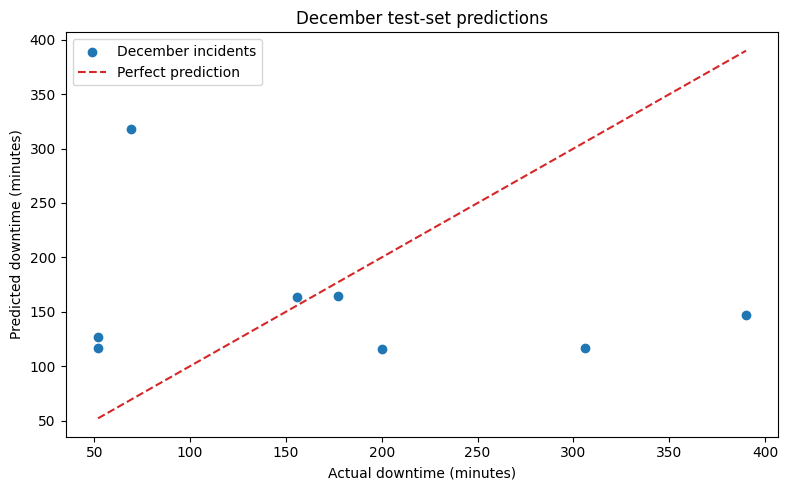

In [6]:
predictions = df.loc[test_mask, ["Asset ID", "Fail Date", "Office", "Event Notes", "Downtime (Min)"]].copy()
predictions = predictions.rename(columns={"Downtime (Min)": "actual_downtime_minutes"})
predictions["predicted_downtime_minutes"] = y_pred
predictions["absolute_error_minutes"] = (
    predictions["actual_downtime_minutes"] - predictions["predicted_downtime_minutes"]
).abs()
display(predictions.sort_values("absolute_error_minutes", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, y_pred, color="tab:blue", label="December incidents")
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
ax.plot([line_min, line_max], [line_min, line_max], "--", color="tab:red", label="Perfect prediction")
ax.set_xlabel("Actual downtime (minutes)")
ax.set_ylabel("Predicted downtime (minutes)")
ax.set_title("December test-set predictions")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "december_predictions.png", dpi=200)
plt.show()
plt.close(fig)

In [7]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["regressor"].feature_importances_
feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)
display(feature_importance)

metrics.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
predictions.to_csv(OUTPUT_DIR / "december_predictions.csv", index=False)
feature_importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
print(f"Saved outputs to {OUTPUT_DIR.resolve()}")

,feature,importance
30,categorical__Event Notes_Lack of storage,0.469687
1,numeric__fail_day_of_week,0.093626
0,numeric__fail_month_number,0.082855
27,categorical__Event Notes_Hardware issue,0.075892
20,categorical__Office_Brisbane,0.057771
13,categorical__Asset ID_402,0.046582
28,categorical__Event Notes_Insufficient memory,0.030488
23,categorical__Office_Macquarie Park,0.018998
4,categorical__Asset ID_103,0.014619
10,categorical__Asset ID_301,0.013707


Saved outputs to C:\Users\user\Documents\GitHub\Data_Analysis_Fujitsu\output\ml
